<a href="https://colab.research.google.com/github/isisjardim/Ciclo-14-Pretalab-Python-Github/blob/main/Aula_3_Pr%C3%A1tica_Estat%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prática de exercícios de estatística em Python

## Objetivos

* Aplicar conceitos de estatística descritiva ao dataset Coffee Sales
* Analisar distribuições e probabilidades
* Realizar amostragem e testes de hipóteses
* Interpretar resultados de forma crítica e aplicada

## Dataset: `vendas_cafeteria.csv`

Cada linha representa uma venda individual em uma cafeteria, incluindo:
- Data e hora da compra  
- Tipo de café vendido  
- Valor pago  
- Tipo de pagamento  
- Período do dia, dia da semana e mês  

Arquivo: https://drive.google.com/file/d/1JUF9uI-nC0bbcWjBw8hnPWRcGNLfWNqI/view?usp=sharing

In [ ]:
#Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurações
sns.set(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (8,4)
pd.options.plotting.backend = "plotly"

In [ ]:
# Carregar o dataset
df = pd.read_csv("vendas_cafeteria.csv")

## Aquecimento


1. Mostrar as 5 primeiras linhas.
2. Exibir informações e tipos de dados (.info()).

In [ ]:
df.head()

,hora_do_dia,tipo_pagamento,valor,nome_cafe,periodo_do_dia,dia_da_semana,mes,ordem_dia,ordem_mes,data,hora
0,10,cartão,38.7,Latte,Manhã,Sex,Março,5,3,2024-03-01,10:15:50.520000
1,12,cartão,38.7,Chocolate Quente,Tarde,Sex,Março,5,3,2024-03-01,12:19:22.539000
2,12,cartão,38.7,Chocolate Quente,Tarde,Sex,Março,5,3,2024-03-01,12:20:18.089000
3,13,cartão,28.9,Café Americano,Tarde,Sex,Março,5,3,2024-03-01,13:46:33.006000
4,13,cartão,38.7,Latte,Tarde,Sex,Março,5,3,2024-03-01,13:48:14.626000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hora_do_dia     3547 non-null   int64  
 1   tipo_pagamento  2698 non-null   object 
 2   valor           3547 non-null   float64
 3   nome_cafe       3547 non-null   object 
 4   periodo_do_dia  3547 non-null   object 
 5   dia_da_semana   3547 non-null   object 
 6   mes             3547 non-null   object 
 7   ordem_dia       3547 non-null   int64  
 8   ordem_mes       3547 non-null   int64  
 9   data            3547 non-null   object 
 10  hora            3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


## Exercício 1 — Estatística descritiva


1. Calcule as estatísticas descritivas (.describe()) e observe as medidas de posição e dispersão (média, mediana, desvio padrão). Responda:
- O que a média representa?

- O que o desvio padrão mostra sobre as vendas?

- Compare o valor da média com o da mediana

2. Escolha uma das variáveis, visualize suas estatísticas com diagrama de caixa (BoxPlot) e responda: os dados são mais concentrados ou dispersos? existem valores atípicos (outliers)?

In [ ]:
df.describe()

,hora_do_dia,valor,ordem_dia,ordem_mes
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


Text(0.5, 0, 'Valor')

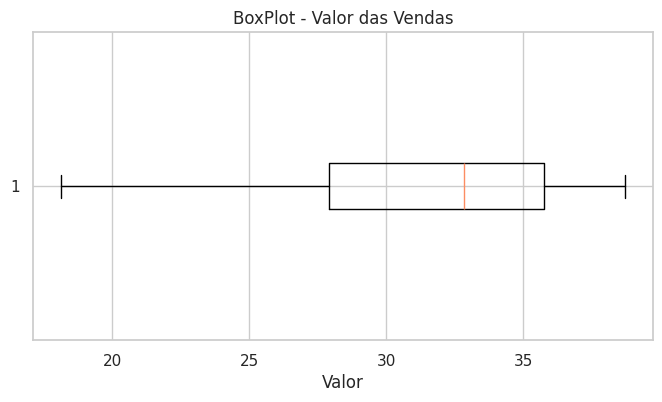

In [ ]:
plt.boxplot(df['valor'], vert=False)
plt.title('BoxPlot - Valor das Vendas')
plt.xlabel('Valor')

{'whiskers': [<matplotlib.lines.Line2D at 0x7f7f49a12900>,
 'caps': [<matplotlib.lines.Line2D at 0x7f7f49a12ed0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f7f49a12660>],
 'medians': [<matplotlib.lines.Line2D at 0x7f7f49a13440>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f7f49a13710>],
 'means': []}

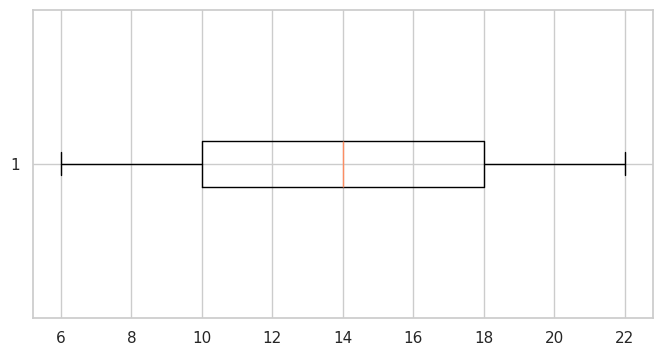

In [ ]:
plt.boxplot(df['hora_do_dia'], vert=False)

## Exercício 2 — Distribuição de Probabilidade

1. Analise o comportamento da variável `valor` e responda:
* A distribuição é simétrica ou assimétrica?

* Existem valores atípicos (outliers)?

* O comportamento se aproxima de uma distribuição normal?

In [ ]:
df['valor'].plot(kind='hist', title='Histograma Valor de Vendas')

Text(0.5, 1.0, 'Histograma Valor de Vendas')

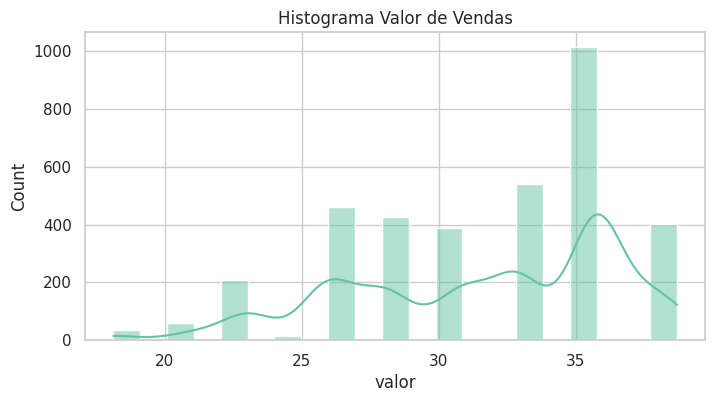

In [ ]:
sns.histplot(df['valor'], kde=True)
plt.title('Histograma Valor de Vendas')

<Axes: xlabel='hora_do_dia', ylabel='Count'>

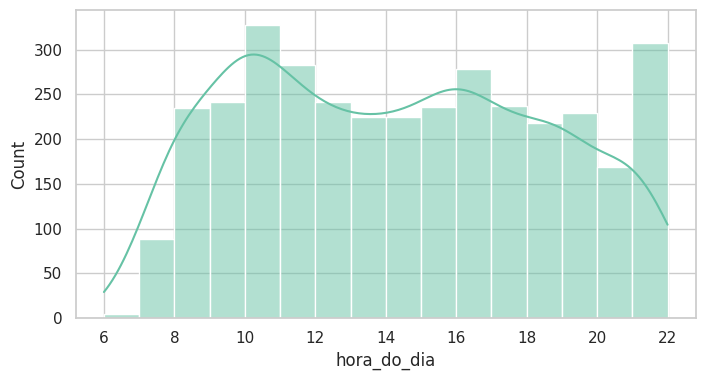

In [ ]:
sns.histplot(df['hora_do_dia'], kde=True)

In [ ]:
df['hora_do_dia'].plot(kind='hist')

## Exercício 3 — Probabilidade aplicada


1. Qual é a probabilidade empírica (calculada a partir dos dados) de uma venda ser maior que R$ 20, R$ 40 ou R$ 60?


2. Supondo uma distribuição normal, qual a probabilidade teórica de uma venda estar entre R$20 e R$40?



In [ ]:
p_maior_20 = np.sum(df['valor']>20)/len(df['valor'])
p_maior_20

np.float64(0.9898505779531999)

In [ ]:
np.mean(df['valor']>20)

np.float64(0.9898505779531999)

In [ ]:
np.mean(df['valor']>40)

np.float64(0.0)

In [ ]:
np.mean(df['valor']>60)

np.float64(0.0)

In [ ]:
media = df['valor'].mean()
media

np.float64(31.64521567521849)

In [ ]:
desvio = df['valor'].std()
desvio

4.877753703590957

Text(0, 0.5, 'Densidade de probabilidade')

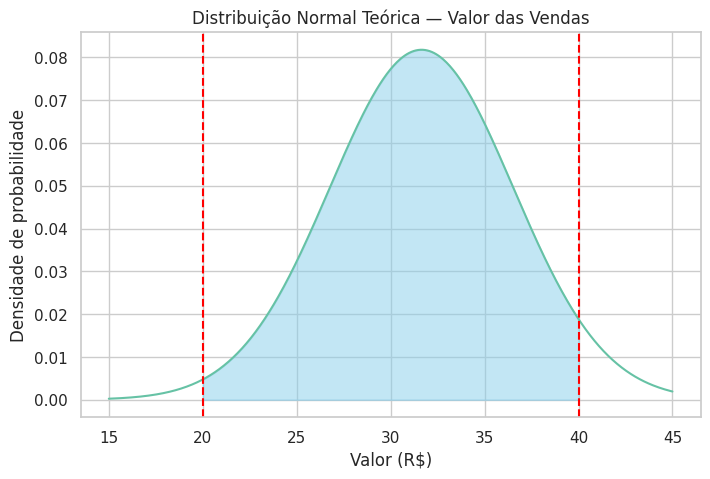

In [ ]:
from scipy.stats import norm
# Gerar intervalo de valores para o eixo x
x = np.linspace(15, 45, 500)

# Calcular a densidade da distribuição normal
y = norm.pdf(x, media, desvio)

# Plotar a curva da distribuição normal
plt.figure(figsize=(8,5))
plt.plot(x, y, label='Distribuição Normal (Valor das Vendas)')

# Área entre 20 e 40
x_fill = np.linspace(20, 40, 300)
y_fill = norm.pdf(x_fill, media, desvio)
plt.fill_between(x_fill, y_fill, color='skyblue', alpha=0.5, label='Área entre R$20 e R$40')

# Linhas de referência
plt.axvline(20, color='red', linestyle='--')
plt.axvline(40, color='red', linestyle='--')

plt.title("Distribuição Normal Teórica — Valor das Vendas")
plt.xlabel("Valor (R$)")
plt.ylabel("Densidade de probabilidade")

In [ ]:
p_menor_20 = norm.cdf(20, media, desvio)
p_menor_40 = norm.cdf(40, media, desvio)

p_maior_20_menor_40 = p_menor_40 - p_menor_20
p_maior_20_menor_40

np.float64(0.948144800418718)

| Conceito                  | Explicação simples                           |
| ------------------------- | -------------------------------------------- |
| **Média (μ)**             | O valor mais comum (centro da curva)         |
| **Desvio padrão (σ)**     | Mede o quanto os valores se afastam da média |
| **Distribuição normal**   | A famosa curva em forma de sino              |
| **Probabilidade teórica** | Área sob a curva entre dois valores          |
| **Função `norm.cdf`**     | Mede “quanta área tem até um ponto”          |


## Exercício 4 — Amostragem

1. Crie três amostras aleatórias dos valores de venda: n = 30, 100, 300.
2. Compare as médias dessas amostras com a média geral da variável.

In [ ]:
media_geral = df['valor'].mean()
media_geral

np.float64(31.64521567521849)

In [ ]:
amostra_30 = df['valor'].sample(30, random_state=17)
amostra_100 = df['valor'].sample(100, random_state=2)
amostra_300 = df['valor'].sample(300, random_state=5)

In [ ]:
amostra_30.mean()

np.float64(31.644000000000005)

In [ ]:
amostra_100.mean()

np.float64(31.575400000000005)

In [ ]:
amostra_300.mean()

np.float64(31.55906666666667)

## Exercício 5 — Teste de Hipóteses

Comparando métodos de pagamento

Hipótese: “O valor médio gasto por clientes que pagam em dinheiro é igual ao dos que pagam com cartão.”

| Tipo de teste | ttest_ind() — duas amostras independentes | https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

### Interpretação:

- Se p < 0.05, significa que os valores médios gastos em cartão e dinheiro são estatisticamente diferentes.

- Isso pode indicar comportamento de consumo distinto entre os dois grupos.

Hipótese nula: O valor médio gasto por clientes que pagam em dinheiro é igual ao dos que pagam com cartão.

Hipótese alternativa: Os valores médios são diferentes.

In [ ]:
cartao = df[df['tipo_pagamento'] == 'cartão']['valor']
dinheiro = df[df['tipo_pagamento'] == 'dinheiro']['valor']

In [ ]:
from scipy.stats import ttest_ind

t_stat, p_valor = ttest_ind(cartao, dinheiro)

In [ ]:
p_valor

np.float64(0.9120677905055796)

/tmp/ipython-input-4278093652.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0, 0.5, 'Valor da Venda (R$)')

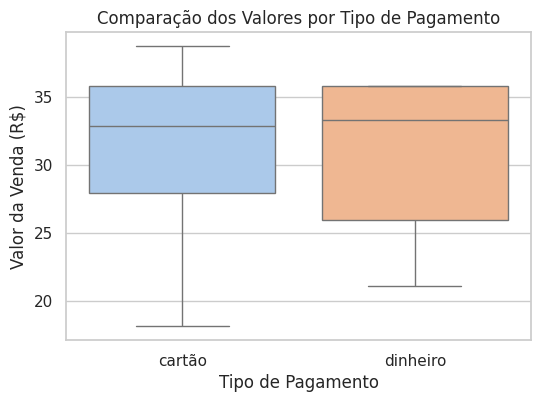

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criar boxplot comparando os métodos de pagamento
plt.figure(figsize=(6,4))
sns.boxplot(x='tipo_pagamento', y='valor', data=df, palette='pastel')
plt.title("Comparação dos Valores por Tipo de Pagamento")
plt.xlabel("Tipo de Pagamento")
plt.ylabel("Valor da Venda (R$)")